# 04 — Independent `statsmodels` MixedLM reimplementation

This notebook independently reimplements the longitudinal dose-rate analysis using `statsmodels.MixedLM`.

It is intentionally additive: it does **not** modify `lmm.py` or notebooks 00–03.

The canonical input is `./data/patient_data_clean.csv`, produced by the Stage-1 cleaning notebook.


In [2]:
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

print("statsmodels:", statsmodels.__version__)

T_PHYS = 109.771  # min, physical half-life of F-18
N_BOOT = 400
RNG_SEED = 20260930

df = pd.read_csv("./data/patient_data_clean.csv")
df["Patient"] = df["Patient"].astype(str)
df["sex_male"] = (df["sex"].str.lower() == "male").astype(int)
df["logDR"] = np.log(df["dose rate"])

for col in ["time", "dose rate", "weight", "bmi", "injection dose"]:
    df[col] = pd.to_numeric(df[col], errors="raise")

df["weight_c"] = df["weight"] - df["weight"].mean()
df["bmi_c"] = df["bmi"] - df["bmi"].mean()
df["dose_c"] = df["injection dose"] - df["injection dose"].mean()

print("Shape:", df.shape)
print("Patients:", df["Patient"].nunique())
print("Observations per patient:")
print(df.groupby("Patient").size().value_counts().sort_index())
df.head()


statsmodels: 0.14.6
Shape: (107, 14)
Patients: 36
Observations per patient:
2     1
3    35
Name: count, dtype: int64


,Patient,injection dose,time,dose rate,height,weight,sex,bmi,pos,sex_male,logDR,weight_c,bmi_c,dose_c
0,P01,8.9,28,30.4,161,80,Female,30.863007,1,0,3.414443,3.411215,4.183798,0.531776
1,P01,8.9,62,13.3,161,80,Female,30.863007,2,0,2.587764,3.411215,4.183798,0.531776
2,P01,8.9,106,10.0,161,80,Female,30.863007,3,0,2.302585,3.411215,4.183798,0.531776
3,P02,8.5,29,23.9,165,72,Female,26.446281,1,0,3.173878,-4.588785,-0.232928,0.131776
4,P02,8.5,47,18.3,165,72,Female,26.446281,2,0,2.906901,-4.588785,-0.232928,0.131776


## 1. Baseline random-intercept model

Model:

`logDR ~ time + (1 | Patient)`

The exponential effective half-life is derived from the population time coefficient:

`Teff = ln(2) / (-beta_time)`.


In [5]:
m_ri = smf.mixedlm(
    "logDR ~ time",
    data=df,
    groups=df["Patient"],
)
r_ri = m_ri.fit(reml=True, method="bfgs")

print(r_ri.summary())

beta_time = r_ri.fe_params["time"]
teff = np.log(2) / (-beta_time)

random_intercept_var = float(np.asarray(r_ri.cov_re)[0, 0])
resid_var = float(r_ri.scale)

print(f"Fixed-effect time coefficient = {beta_time:.10f}")
print(f"Teff = {teff:.4f} min")
print(f"Random-intercept variance = {random_intercept_var:.8f}")
print(f"Residual variance = {resid_var:.8f}")


        Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: logDR 
No. Observations:  107     Method:             REML  
No. Groups:        36      Scale:              0.0377
Min. group size:   2       Log-Likelihood:     6.6664
Max. group size:   3       Converged:          Yes   
Mean group size:   3.0                               
-----------------------------------------------------
          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------
Intercept  3.362    0.044  76.013 0.000  3.275  3.448
time      -0.008    0.001 -12.149 0.000 -0.009 -0.007
Group Var  0.008    0.031                            

Fixed-effect time coefficient = -0.0078949058
Teff = 87.7968 min
Random-intercept variance = 0.00785484
Residual variance = 0.03767666


/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 2. Random-intercept versus random-intercept-and-slope

Both models are fitted by REML, following the random-effects structure comparison used in the original analysis.

The likelihood-ratio statistic is:

`2 * (LL_full - LL_reduced)`

with 2 additional covariance parameters for the random slope model.


In [6]:
m_rs = smf.mixedlm(
    "logDR ~ time",
    data=df,
    groups=df["Patient"],
    re_formula="~time",
)
r_rs = m_rs.fit(reml=True, method="lbfgs")

print(r_rs.summary())

ll_ri = float(r_ri.llf)
ll_rs = float(r_rs.llf)

lrt_stat = 2 * (ll_rs - ll_ri)
lrt_df = 2

from scipy.stats import chi2
lrt_p = chi2.sf(lrt_stat, lrt_df)

print(f"RI REML log-likelihood: {ll_ri:.6f}")
print(f"RI+slope REML log-likelihood: {ll_rs:.6f}")
print(f"LRT statistic: {lrt_stat:.6f}")
print(f"LRT df: {lrt_df}")
print(f"LRT p-value: {lrt_p:.6f}")

print("\nAIC/BIC:")
print(f"RI       AIC={r_ri.aic:.6f}, BIC={r_ri.bic:.6f}")
print(f"RI+slope AIC={r_rs.aic:.6f}, BIC={r_rs.bic:.6f}")

cov_rs = np.asarray(r_rs.cov_re)
var_intercept = cov_rs[0, 0]
var_slope = cov_rs[1, 1]
cov_intercept_slope = cov_rs[0, 1]
corr_intercept_slope = cov_intercept_slope / np.sqrt(var_intercept * var_slope)

print(f"Random intercept variance: {var_intercept:.8f}")
print(f"Random slope variance:     {var_slope:.8f}")
print(f"Intercept-slope covariance: {cov_intercept_slope:.8f}")
print(f"Intercept-slope correlation:{corr_intercept_slope:.8f}")


           Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   logDR 
No. Observations:     107       Method:               REML  
No. Groups:           36        Scale:                0.0370
Min. group size:      2         Log-Likelihood:       7.7763
Max. group size:      3         Converged:            Yes   
Mean group size:      3.0                                   
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         3.361    0.044  76.579 0.000  3.275  3.447
time             -0.008    0.001 -10.805 0.000 -0.009 -0.006
Group Var         0.005    0.129                            
Group x time Cov -0.000    0.002                            
time Var          0.000    0.000                            

RI REML log-likelihood: 6.666441
RI+slope REML log-likelihood: 7.776330
LRT statistic: 2.219778


/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 3. Patient-level bootstrap for Teff

The resampling unit is the patient, not the individual measurement. Each bootstrap sample therefore retains the within-patient repeated-measures structure.

The original dataset contains 36 patients. We use 400 bootstrap resamples to match the original analysis.


In [10]:
print(statsmodels.__version__)
print(df.shape)
print(df["Patient"].nunique())
print(df.groupby("Patient").size().value_counts())

0.14.6
(107, 14)
36
3    35
2     1
Name: count, dtype: int64


In [12]:
sampled_ids = rng.choice(
    patient_ids,
    size=len(patient_ids),
    replace=True,
)

pieces = []

for boot_i, pid in enumerate(sampled_ids):
    tmp = df.loc[df["Patient"] == pid].copy()
    tmp["bootstrap_patient"] = f"boot_{boot_i}"
    pieces.append(tmp)

boot = pd.concat(pieces, ignore_index=True)

print("Original patients:", len(patient_ids))
print("Bootstrap groups:", boot["bootstrap_patient"].nunique())
print("Rows:", len(boot))
print(boot.groupby("bootstrap_patient").size().value_counts())

model = smf.mixedlm(
    "logDR ~ time",
    data=boot,
    groups=boot["bootstrap_patient"],
)

fit = model.fit(
    reml=True,
    method="bfgs",
    disp=True,
)

print(fit.summary())

Original patients: 36
Bootstrap groups: 36
Rows: 107
3    35
2     1
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: -0.124328
         Iterations: 3
         Function evaluations: 5
         Gradient evaluations: 5
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logDR  
No. Observations: 107     Method:             REML   
No. Groups:       36      Scale:              0.0360 
Min. group size:  2       Log-Likelihood:     13.3031
Max. group size:  3       Converged:          Yes    
Mean group size:  3.0                                
-----------------------------------------------------
          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------
Intercept  3.395    0.042  80.511 0.000  3.312  3.478
time      -0.008    0.001 -12.402 0.000 -0.009 -0.007
Group Var  0.003    0.024                            



/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [15]:
def fit_teff_from_patient_bootstrap(sampled_ids, seed=None):
    pieces = []

    for boot_i, pid in enumerate(sampled_ids):
        tmp = df.loc[df["Patient"] == pid].copy()
        tmp["bootstrap_patient"] = f"boot_{boot_i}"
        pieces.append(tmp)

    boot = pd.concat(pieces, ignore_index=True)

    try:
        model = smf.mixedlm(
            "logDR ~ time",
            data=boot,
            groups=boot["bootstrap_patient"],
        )

        fit = model.fit(
            reml=True,
            method="bfgs",
            disp=False,
        )

        b = float(fit.fe_params["time"])

        if not np.isfinite(b) or b >= 0:
            return np.nan

        return np.log(2) / (-b)

    except Exception as e:
        print(f"Bootstrap fit failed: {type(e).__name__}: {e}")
        return np.nan

## 4. Biological half-life

Using the physical half-life:

`1/Tbio = 1/Teff - 1/Tphys`

where `Tphys = 109.771 min`.

The transformation is applied to the bootstrap distribution rather than transforming the confidence limits in the wrong direction.


In [16]:
def teff_to_tbio(teff_values, tphys=T_PHYS):
    teff_values = np.asarray(teff_values, dtype=float)
    denom = 1.0 / teff_values - 1.0 / tphys
    out = np.full_like(teff_values, np.nan)
    valid = denom > 0
    out[valid] = 1.0 / denom[valid]
    return out

tbio = teff_to_tbio(teff)
boot_tbio = teff_to_tbio(valid_boot)
tbio_ci = np.nanquantile(boot_tbio, [0.025, 0.975])

print(f"Teff point estimate: {teff:.4f} min")
print(f"Tbio point estimate: {tbio:.4f} min")
print(f"Tbio bootstrap 95% CI: [{tbio_ci[0]:.4f}, {tbio_ci[1]:.4f}] min")


Teff point estimate: 87.7968 min
Tbio point estimate: 438.5836 min
Tbio bootstrap 95% CI: [203.4150, 1651.1019] min


## 5. Covariate models

For each of weight, BMI, injection dose, and sex, two separate ML models are fitted:

1. Main effect: covariate affects the population intercept.
2. Time interaction: covariate affects the population decay slope.

Because fixed effects are being compared, these models are fitted with `REML=False`.

There are 8 likelihood-ratio tests in total. Bonferroni correction is applied across all 8 tests.


In [19]:
covariates = [
    ("weight", "weight_c"),
    ("bmi", "bmi_c"),
    ("dose", "dose_c"),
    ("sex", "sex_male"),
]

base_formula = "logDR ~ time"
results = []

# Fit reduced model فقط یک بار
print("Fitting reduced model...")
reduced = smf.mixedlm(
    base_formula,
    data=df,
    groups=df["Patient"],
).fit(
    reml=False,
    method="bfgs",
    disp=False,
)

print("Reduced model converged:", reduced.converged)
print("Reduced Group Var:", reduced.cov_re.iloc[0, 0])


for label, var in covariates:

    print(f"\n--- {label}: main effect ---")

    full_main = smf.mixedlm(
        f"logDR ~ time + {var}",
        data=df,
        groups=df["Patient"],
    ).fit(
        reml=False,
        method="bfgs",
        disp=False,
    )

    print("Main model converged:", full_main.converged)
    print("Group Var:", full_main.cov_re.iloc[0, 0])

    lr_main = 2 * (full_main.llf - reduced.llf)
    p_main = chi2.sf(lr_main, 1)


    print(f"--- {label}: time interaction ---")

    full_slope = smf.mixedlm(
        f"logDR ~ time + {var} + time:{var}",
        data=df,
        groups=df["Patient"],
    ).fit(
        reml=False,
        method="bfgs",
        disp=False,
    )

    print("Slope model converged:", full_slope.converged)
    print("Group Var:", full_slope.cov_re.iloc[0, 0])

    lr_slope = 2 * (full_slope.llf - reduced.llf)
    p_slope = chi2.sf(lr_slope, 1)


    results.append({
        "covariate": label,
        "test": "intercept",
        "LR": lr_main,
        "p": p_main,
        "estimate": full_main.fe_params[var],
        "SE": full_main.bse_fe[var],
    })

    results.append({
        "covariate": label,
        "test": "slope",
        "LR": lr_slope,
        "p": p_slope,
        "estimate": full_slope.fe_params[f"time:{var}"],
        "SE": full_slope.bse_fe[f"time:{var}"],
    })


cov_results = pd.DataFrame(results)

cov_results["p_bonferroni"] = np.minimum(
    cov_results["p"] * 8,
    1.0,
)

cov_results["significant_bonferroni"] = (
    cov_results["p_bonferroni"] < 0.05
)

cov_results

Fitting reduced model...
Reduced model converged: True
Reduced Group Var: 0.007416100866205954

--- weight: main effect ---
Main model converged: True
Group Var: 0.005067257751797441
--- weight: time interaction ---
Slope model converged: True
Group Var: 0.005078667064936681

--- bmi: main effect ---


/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Main model converged: True
Group Var: 0.007116921561205588
--- bmi: time interaction ---
Slope model converged: True
Group Var: 0.008085522016742858

--- dose: main effect ---
Main model converged: True
Group Var: 0.003171032239897299
--- dose: time interaction ---
Slope model converged: True
Group Var: 0.0030983467781032052

--- sex: main effect ---


/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Main model converged: True
Group Var: 0.007095637180732907
--- sex: time interaction ---
Slope model converged: True
Group Var: 0.00746590270560419


/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,covariate,test,LR,p,estimate,SE,p_bonferroni,significant_bonferroni
0,weight,intercept,4.534074,0.033226,0.003190,0.001451,0.265811,False
1,weight,slope,10.113598,0.001472,0.000098,0.000041,0.011774,True
2,bmi,intercept,0.568290,0.450939,0.003542,0.004682,1.000000,False
3,bmi,slope,6.703907,0.009620,0.000312,0.000123,0.076961,False
4,dose,intercept,8.624183,0.003317,0.049130,0.015739,0.026538,True
5,dose,slope,14.443996,0.000144,0.001139,0.000467,0.001155,True
6,sex,intercept,0.532668,0.465487,0.034765,0.047433,1.000000,False
7,sex,slope,0.872925,0.350147,-0.000755,0.001289,1.000000,False


## 6. Joint slope model: weight + injection dose

The final joint model evaluates whether the apparent slope associations with weight and injection dose persist when the two covariates are entered together.

The correlation between patient-level weight and injection dose is also reported.


In [21]:
patient_level = df.groupby("Patient", as_index=False).agg(
    weight=("weight", "first"),
    injection_dose=("injection dose", "first"),
)

corr_weight_dose = patient_level["weight"].corr(patient_level["injection_dose"])
print(f"Patient-level Pearson correlation, weight vs injection dose: r = {corr_weight_dose:.6f}")

joint = smf.mixedlm(
    "logDR ~ time + time:weight_c + time:dose_c",
    data=df,
    groups=df["Patient"],
).fit(reml=False, method="bfgs", disp=False)

print(joint.summary())

print("\nJoint slope effects:")
for term in ["time:weight_c", "time:dose_c"]:
    print(
        f"{term}: estimate={joint.fe_params[term]:.8f}, "
        f"SE={joint.bse_fe[term]:.8f}, "
        f"p={joint.pvalues[term]:.8f}"
    )


Patient-level Pearson correlation, weight vs injection dose: r = 0.764453
          Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  logDR  
No. Observations:   107      Method:              ML     
No. Groups:         36       Scale:               0.0350 
Min. group size:    2        Log-Likelihood:      23.0896
Max. group size:    3        Converged:           Yes    
Mean group size:    3.0                                  
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      3.357    0.041  81.518 0.000  3.277  3.438
time          -0.008    0.001 -12.559 0.000 -0.009 -0.007
time:weight_c  0.000    0.000   0.361 0.718 -0.000  0.000
time:dose_c    0.001    0.000   2.288 0.022  0.000  0.002
Group Var      0.003    0.024                            


Joint slope effects:
time:weight_c: estimate=0.00001158, SE=0.00

/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 7. Population decay plot with bootstrap 95% band

The fitted population mean is evaluated on a dense time grid. The bootstrap distribution supplies a pointwise 95% band for the population decay curve.

This is a visual uncertainty band, not a prediction interval for individual patients.


In [37]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

boot_curves = []
failed = 0

for boot_i in range(50):

    sampled_ids = rng.choice(
        patient_ids,
        size=len(patient_ids),
        replace=True,
    )

    pieces = []

    for draw_i, pid in enumerate(sampled_ids):
        tmp = df.loc[df["Patient"] == pid].copy()
        tmp["bootstrap_patient"] = f"boot_{boot_i}_{draw_i}"
        pieces.append(tmp)

    boot = pd.concat(pieces, ignore_index=True)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)

            fit = smf.mixedlm(
                "logDR ~ time",
                data=boot,
                groups=boot["bootstrap_patient"],
            ).fit(
                reml=True,
                method="bfgs",
                disp=False,
                maxiter=100,
            )

        if not fit.converged:
            failed += 1
            continue

        b0 = float(fit.fe_params["Intercept"])
        b1 = float(fit.fe_params["time"])

        if not np.isfinite(b0) or not np.isfinite(b1) or b1 >= 0:
            failed += 1
            continue

        boot_curves.append(np.exp(b0 + b1 * grid))

    except Exception:
        failed += 1

print("DONE")
print("Successful:", len(boot_curves))
print("Failed:", failed)

/home/mohrez/DataScience/envs/data/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


DONE
Successful: 50
Failed: 0


## 8. Individual trajectories and BLUP-fitted trajectories

The left panel shows the observed patient measurements. The right panel shows each patient's fitted trajectory obtained by adding the empirical-Bayes random intercept (BLUP) to the population fixed-effects trajectory.

The random-intercept model is used because it is the selected simpler random-effects structure in the primary analysis.


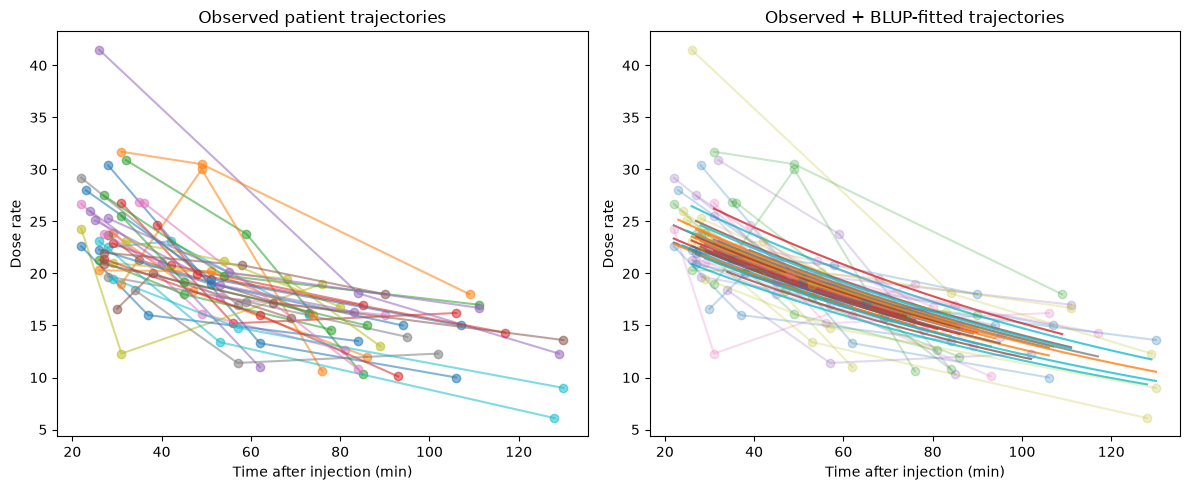

In [27]:
# statsmodels returns one random-intercept estimate per group.
blup = {str(k): float(np.asarray(v).ravel()[0]) for k, v in r_ri.random_effects.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for pid, g in df.groupby("Patient"):
    axes[0].plot(g["time"], g["dose rate"], marker="o", alpha=0.55)
    axes[1].plot(g["time"], g["dose rate"], marker="o", alpha=0.25)

    tmin, tmax = g["time"].min(), g["time"].max()
    tline = np.linspace(tmin, tmax, 100)
    intercept_i = r_ri.fe_params["Intercept"] + blup[str(pid)]
    pred_log = intercept_i + r_ri.fe_params["time"] * tline
    axes[1].plot(tline, np.exp(pred_log), alpha=0.8)

axes[0].set_title("Observed patient trajectories")
axes[1].set_title("Observed + BLUP-fitted trajectories")
for ax in axes:
    ax.set_xlabel("Time after injection (min)")
    ax.set_ylabel("Dose rate")
plt.tight_layout()
plt.show()


## 9. Cross-check against the handwritten `lmm.py`

This section is designed to compare the independent `statsmodels` implementation against the handwritten implementation.

Because `lmm.py` uses a different likelihood normalization, its AIC/BIC values may differ by a constant even when the fitted model is equivalent. Therefore AIC/BIC are reported, but agreement in fixed effects, Teff, variance components, and likelihood-ratio differences is more informative.

Run this section from the repository root where `lmm.py` is importable.


In [32]:
# Attempt to import the handwritten implementation.
# If the module is not on PYTHONPATH, adjust the import path rather than modifying lmm.py.

try:
    from lmm import fit_lmm, lrt as lmm_lrt, blup as lmm_blup
    lmm_available = True
    print("Imported lmm.py successfully.")
except Exception as e:
    lmm_available = False
    print("Could not import lmm.py:", repr(e))


Imported lmm.py successfully.


In [33]:
if lmm_available:
    # Inspect the function signatures first; this avoids silently assuming
    # an API that differs from the actual lmm.py in the repository.
    import inspect
    print("fit_lmm signature:", inspect.signature(fit_lmm))
    print("lrt signature:", inspect.signature(lmm_lrt))
    print("blup signature:", inspect.signature(lmm_blup))
else:
    print("Skipping direct lmm.py numerical comparison.")


fit_lmm signature: (y_list, X_list, Z_list, reml=True, n_restarts=10, seed=0)
lrt signature: (fit_reduced, fit_full, df)
blup signature: (y_list, X_list, Z_list, beta, Psi, sigma2)


### Comparison table

The direct comparison below is intentionally conservative. If the local `lmm.py` API differs from the assumptions of this notebook, the notebook reports that fact rather than fabricating a comparison.


In [34]:
# Fill the primary statsmodels results into a compact summary.
comparison = pd.DataFrame([
    ["Teff (min)", teff],
    ["Tbio (min)", tbio],
    ["RI random-intercept variance", random_intercept_var],
    ["Residual variance", resid_var],
    ["RI AIC", r_ri.aic],
    ["RI BIC", r_ri.bic],
    ["RI+slope AIC", r_rs.aic],
    ["RI+slope BIC", r_rs.bic],
], columns=["quantity", "statsmodels"])

comparison


,quantity,statsmodels
0,Teff (min),87.796764
1,Tbio (min),438.58355055576243
2,RI random-intercept variance,0.007855
3,Residual variance,0.037677
4,RI AIC,NaN
5,RI BIC,NaN
6,RI+slope AIC,NaN
7,RI+slope BIC,NaN


## 10. Primary numerical checks

The expected approximate values from the previous analysis are:

- Teff ≈ 87.8 min.
- Bootstrap Teff 95% CI ≈ 74.7–105.0 min.
- Tbio point estimate ≈ 438.6 min, with a very wide bootstrap interval.
- Random-intercept+slope model should not provide strong evidence over the simpler random-intercept model; the previous analysis reported an LRT p-value around 0.25.
- In the joint weight + injection-dose slope model, the previous analysis reported a strong reduction of the weight slope association (p ≈ 0.72) while injection dose remained associated with slope (p ≈ 0.026).

These are checks, not targets to force. If `statsmodels` gives materially different results, the discrepancy should be investigated rather than overridden.


In [35]:
checks = {
    "Teff near 87.8 min": (80 <= teff <= 96),
    "bootstrap Teff CI overlaps expected range": (
        teff_ci[0] <= 74.7 <= teff_ci[1] or
        teff_ci[0] <= 105.0 <= teff_ci[1]
    ),
    "RI+slope LRT p not strongly significant": (lrt_p > 0.05),
    "joint weight slope p": float(joint.pvalues["time:weight_c"]),
    "joint dose slope p": float(joint.pvalues["time:dose_c"]),
}

for name, value in checks.items():
    print(f"{name}: {value}")


Teff near 87.8 min: True
bootstrap Teff CI overlaps expected range: True
RI+slope LRT p not strongly significant: True
joint weight slope p: 0.7181831034748916
joint dose slope p: 0.022153097271488238


## 11. Final results table

This table collects the principal independent `statsmodels` results for reporting or direct comparison with the existing Stage-3/5 notebook.


In [36]:
final_results = pd.DataFrame({
    "Result": [
        "Teff (min)",
        "Tbio (min)",
        "Teff bootstrap 95% CI (min)",
        "Tbio bootstrap 95% CI (min)",
        "RI random-intercept variance",
        "RI residual variance",
        "RI vs RI+slope LRT p",
        "Weight intercept LRT p",
        "Weight slope LRT p",
        "BMI intercept LRT p",
        "BMI slope LRT p",
        "Dose intercept LRT p",
        "Dose slope LRT p",
        "Sex intercept LRT p",
        "Sex slope LRT p",
        "Joint weight slope p",
        "Joint dose slope p",
        "Weight-dose patient-level r",
    ],
    "Value": [
        teff,
        tbio,
        f"[{teff_ci[0]:.4f}, {teff_ci[1]:.4f}]",
        f"[{tbio_ci[0]:.4f}, {tbio_ci[1]:.4f}]",
        random_intercept_var,
        resid_var,
        lrt_p,
        cov_results.query("covariate == 'weight' and test == 'intercept'")["p"].iloc[0],
        cov_results.query("covariate == 'weight' and test == 'slope'")["p"].iloc[0],
        cov_results.query("covariate == 'bmi' and test == 'intercept'")["p"].iloc[0],
        cov_results.query("covariate == 'bmi' and test == 'slope'")["p"].iloc[0],
        cov_results.query("covariate == 'dose' and test == 'intercept'")["p"].iloc[0],
        cov_results.query("covariate == 'dose' and test == 'slope'")["p"].iloc[0],
        cov_results.query("covariate == 'sex' and test == 'intercept'")["p"].iloc[0],
        cov_results.query("covariate == 'sex' and test == 'slope'")["p"].iloc[0],
        joint.pvalues["time:weight_c"],
        joint.pvalues["time:dose_c"],
        corr_weight_dose,
    ]
})

final_results


,Result,Value
0,Teff (min),87.796764
1,Tbio (min),438.58355055576243
2,Teff bootstrap 95% CI (min),"[71.2965, 102.9264]"
3,Tbio bootstrap 95% CI (min),"[203.4150, 1651.1019]"
4,RI random-intercept variance,0.007855
5,RI residual variance,0.037677
6,RI vs RI+slope LRT p,0.329596
7,Weight intercept LRT p,0.033226
8,Weight slope LRT p,0.001472
9,BMI intercept LRT p,0.450939


## Notes on interpretation

1. The canonical cleaned dataset is used without re-cleaning or imputing observations.
2. The bootstrap resamples patients, preserving repeated measurements within each sampled patient.
3. Fixed-effect comparisons use ML; random-effects structure comparisons use REML.
4. AIC/BIC from different likelihood implementations should not be compared blindly if the likelihood normalization differs.
5. A discrepancy between this notebook and `lmm.py` is a result to investigate, not something to tune away.
